In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# 1. Load dataset kurs (2019-2024)
kurs_df = pd.read_csv('/content/USD_IDR_Historical_Data_Jan2018_First.csv')
kurs_df['Date'] = pd.to_datetime(kurs_df['Date'])
kurs_df.set_index('Date', inplace=True)
kurs_df.sort_index(inplace=True)

kurs_df

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2018-01-01,"13,567.50","13,567.50","13,567.50","13,567.50",NaN,0.00%
2018-01-02,"13,517.50","13,537.50","13,555.50","13,514.50",NaN,-0.37%
2018-01-03,"13,478.00","13,500.00","13,509.00","13,476.00",NaN,-0.29%
2018-01-04,"13,423.50","13,466.50","13,481.50","13,411.50",NaN,-0.40%
2018-01-05,"13,415.50","13,413.50","13,435.50","13,392.50",NaN,-0.06%
...,...,...,...,...,...,...
2024-12-25,"16,185.00","16,185.00","16,185.00","16,185.00",NaN,0.00%
2024-12-26,"16,185.00","16,185.00","16,185.00","16,185.00",NaN,0.00%
2024-12-27,"16,230.00","16,207.50","16,260.00","16,205.00",NaN,0.28%


In [ ]:
# prompt: Konversi Kolom 'Date' ke Format Datetime

import pandas as pd

# 'Date' is already the index and in datetime format.
# If you need to access it as a column, you can reset the index:
kurs_df = kurs_df.reset_index()

# Now you can access 'Date' as a column if needed:
# kurs_df['Date']
# ... (your existing code) ...

In [ ]:
# 3. Urutkan Data Berdasarkan Tanggal
# Assuming 'kurs_df' from previous cell contains your data
data = kurs_df.copy()  # Create a copy of kurs_df and assign it to data
data = data.sort_values('Date')
print("\nSetelah Pengurutan Tanggal:")
print(data.head())


Setelah Pengurutan Tanggal:
        Date      Price       Open       High        Low Vol. Change %
0 2018-01-01  13,567.50  13,567.50  13,567.50  13,567.50  NaN    0.00%
1 2018-01-02  13,517.50  13,537.50  13,555.50  13,514.50  NaN   -0.37%
2 2018-01-03  13,478.00  13,500.00  13,509.00  13,476.00  NaN   -0.29%
3 2018-01-04  13,423.50  13,466.50  13,481.50  13,411.50  NaN   -0.40%
4 2018-01-05  13,415.50  13,413.50  13,435.50  13,392.50  NaN   -0.06%


In [ ]:
# 4. Pembersihan Kolom Numerik (Price, Open, High, Low)
# Hilangkan koma dan ubah ke float
for col in ['Price', 'Open', 'High', 'Low']:
    # Check if the column type is object (string or mixed) before applying str methods
    if data[col].dtype == object:
        data[col] = data[col].str.replace(',', '').astype(float)
    else:
        # If already numeric, no need for string replacement
        data[col] = data[col].astype(float)
print("\nSetelah Pembersihan Kolom Numerik:")
print(data[['Date', 'Price', 'Open', 'High', 'Low']].head())


Setelah Pembersihan Kolom Numerik:
        Date    Price     Open     High      Low
0 2018-01-01  13567.5  13567.5  13567.5  13567.5
1 2018-01-02  13517.5  13537.5  13555.5  13514.5
2 2018-01-03  13478.0  13500.0  13509.0  13476.0
3 2018-01-04  13423.5  13466.5  13481.5  13411.5
4 2018-01-05  13415.5  13413.5  13435.5  13392.5


In [ ]:
# 5. Penanganan Missing Value
# Cek missing value
print("\nJumlah Missing Value:")
print(data.isnull().sum())


Jumlah Missing Value:
Date          0
Price         0
Open          0
High          0
Low           0
Vol.        782
Change %      0
dtype: int64


In [ ]:
# Kolom 'Vol.' memiliki banyak NaN, isi dengan 0 atau interpolasi
# Convert to string before applying str.replace
data['Vol.'] = data['Vol.'].astype(str).str.replace('K', 'e3').fillna('0').astype(float)  # Konversi K ke ribuan
data['Vol.'] = data['Vol.'].replace(0, method='ffill')  # Isi 0 dengan nilai sebelumnya
print("\nSetelah Penanganan Missing Value di Vol.:")
print(data[['Date', 'Vol.']].head())


Setelah Penanganan Missing Value di Vol.:
        Date  Vol.
0 2018-01-01   NaN
1 2018-01-02   NaN
2 2018-01-03   NaN
3 2018-01-04   NaN
4 2018-01-05   NaN


<ipython-input-115-a7590f6f5e0f>:4: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  data['Vol.'] = data['Vol.'].replace(0, method='ffill')  # Isi 0 dengan nilai sebelumnya


In [ ]:
# Kolom 'Change %' diubah ke float (hilangkan %)
# Ensure the column is treated as a string before using .str
data['Change %'] = data['Change %'].astype(str).str.replace('%', '').astype(float) / 100
print("\nSetelah Konversi Change %:")
print(data[['Date', 'Change %']].head())


Setelah Konversi Change %:
        Date  Change %
0 2018-01-01    0.0000
1 2018-01-02   -0.0037
2 2018-01-03   -0.0029
3 2018-01-04   -0.0040
4 2018-01-05   -0.0006


In [ ]:
# 6. Penanganan Outlier (Opsional)
# Deteksi outlier menggunakan IQR pada kolom 'Price'
Q1 = data['Price'].quantile(0.25)
Q3 = data['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['Price'] < lower_bound) | (data['Price'] > upper_bound)]
print("\nOutlier pada Price:")
print(outliers[['Date', 'Price']])


Outlier pada Price:
Empty DataFrame
Columns: [Date, Price]
Index: []


In [ ]:
# (Opsional) Ganti outlier dengan median
data['Price'] = np.where((data['Price'] < lower_bound) | (data['Price'] > upper_bound),
                         data['Price'].median(), data['Price'])

In [ ]:
# 2. Load dataset pendapatan negara (2019-2024)
pendapatan_19_21 = pd.read_csv('/content/Actual Government Revenues, 2019-2021.csv')
pendapatan_22_24 = pd.read_csv('/content/Actual Government Revenues, 2022-2024.csv')

In [ ]:
# Gabungkan dataset pendapatan
pendapatan_df = pd.concat([pendapatan_19_21, pendapatan_22_24])
# Check if the date column is named 'Month', otherwise identify the correct column name
# and replace 'Actual Date' with that name

# Check if either 'Month' or 'Date' exists as a column,
# If not, assume the first column is the date column and rename it to 'Date'.
date_column = None
for col in ['Month', 'Date', 'Source of Revenues - Pendapatan Negara']:  # Added 'Source of Revenues - Pendapatan Negara'
    if col in pendapatan_df.columns:
        date_column = col
        break

if date_column is None:
    date_column = pendapatan_df.columns[0]  # Assuming first column is date
    pendapatan_df = pendapatan_df.rename(columns={date_column: 'Date'})
else:
    # Rename the identified date column to 'Date'
    pendapatan_df = pendapatan_df.rename(columns={date_column: 'Date'})

# Convert 'Date' column to datetime if it's not already
if pendapatan_df['Date'].dtype != 'datetime64[ns]':
    # Skip rows that are not parsable as dates
    pendapatan_df['Date'] = pd.to_datetime(pendapatan_df['Date'], errors='coerce')
    # Drop rows with NaT (Not a Time) values in the 'Date' column
    pendapatan_df = pendapatan_df.dropna(subset=['Date'])

pendapatan_df.set_index('Date', inplace=True)
pendapatan_df.sort_index(inplace=True)

<ipython-input-120-4e95132eaf92>:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pendapatan_df['Date'] = pd.to_datetime(pendapatan_df['Date'], errors='coerce')


In [ ]:
# Gabungkan dataset pendapatan
pendapatan_df = pd.concat([pendapatan_19_21, pendapatan_22_24])
# Check if the date column is named 'Month', otherwise identify the correct column name
# and replace 'Actual Date' with that name

# Check if either 'Month' or 'Date' exists as a column,
# If not, assume the first column is the date column and rename it to 'Date'.
date_column = None
# Here's where the issue most likely is. It is checking if 'Month' or 'Date' or 'Source of Revenues - Pendapatan Negara'
# is in the list of columns and picking whichever comes first. It's possible your date column
# is named something else
for col in ['Month', 'Date', 'Source of Revenues - Pendapatan Negara', 'Actual Date']: # Added 'Actual Date'
    if col in pendapatan_df.columns:
        date_column = col
        break

if date_column is None:
    date_column = pendapatan_df.columns[0]  # Assuming first column is date
    pendapatan_df = pendapatan_df.rename(columns={date_column: 'Date'})
else:
    # Rename the identified date column to 'Date'
    pendapatan_df = pendapatan_df.rename(columns={date_column: 'Date'})

# Convert 'Date' column to datetime if it's not already
if pendapatan_df['Date'].dtype != 'datetime64[ns]':
    # Skip rows that are not parsable as dates
    pendapatan_df['Date'] = pd.to_datetime(pendapatan_df['Date'], errors='coerce')
    # Drop rows with NaT (Not a Time) values in the 'Date' column
    pendapatan_df = pendapatan_df.dropna(subset=['Date'])

pendapatan_df.set_index('Date', inplace=True)
pendapatan_df.sort_index(inplace=True)

<ipython-input-121-9ba4319c0316>:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pendapatan_df['Date'] = pd.to_datetime(pendapatan_df['Date'], errors='coerce')


In [ ]:
# Gabungkan dataset pendapatan
pendapatan_df = pd.concat([pendapatan_19_21, pendapatan_22_24])
# Check if the date column is named 'Month', otherwise identify the correct column name
# and replace 'Actual Date' with that name

# Check if either 'Month' or 'Date' exists as a column,
# If not, assume the first column is the date column and rename it to 'Date'.
date_column = None
# Here's where the issue most likely is. It is checking if 'Month' or 'Date' or 'Source of Revenues - Pendapatan Negara'
# is in the list of columns and picking whichever comes first. It's possible your date column
# is named something else.
# Add any potential date column name here in the column list.
# For example, if your actual date column is named "Date1", add it to the list:
for col in ['Month', 'Date', 'Source of Revenues - Pendapatan Negara', 'Actual Date', "Date1"]:  # Add any additional potential date column names
    if col in pendapatan_df.columns:
        date_column = col
        break

if date_column is None:
    date_column = pendapatan_df.columns[0]  # Assuming first column is date
    pendapatan_df = pendapatan_df.rename(columns={date_column: 'Date'})
else:
    # Rename the identified date column to 'Date'
    pendapatan_df = pendapatan_df.rename(columns={date_column: 'Date'})

# Convert 'Date' column to datetime if it's not already
if pendapatan_df['Date'].dtype != 'datetime64[ns]':
    # Skip rows that are not parsable as dates
    pendapatan_df['Date'] = pd.to_datetime(pendapatan_df['Date'], errors='coerce')
    # Drop rows with NaT (Not a Time) values in the 'Date' column
    pendapatan_df = pendapatan_df.dropna(subset=['Date'])

pendapatan_df.set_index('Date', inplace=True)
pendapatan_df.sort_index(inplace=True)

<ipython-input-122-1e3b4dfd4207>:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pendapatan_df['Date'] = pd.to_datetime(pendapatan_df['Date'], errors='coerce')


In [ ]:
# prompt: Gabungkan kurs dan pendapatan

import pandas as pd
# Assuming 'data' (kurs_df) and 'pendapatan_df' are already defined and processed as in your previous code.

# Merge the two DataFrames based on the 'Date' index.  You'll need to ensure the date formats match.
merged_df = pd.merge(data, pendapatan_df, left_on='Date', right_index=True, how='inner')

# Display the merged DataFrame
print("\nMerged DataFrame:")
print(merged_df.head())



Merged DataFrame:
Empty DataFrame
Columns: [Date, Price, Open, High, Low, Vol., Change %, Unnamed: 1, Unnamed: 2, Unnamed: 3]
Index: []


In [ ]:
# 3. Feature Engineering untuk XGBoost
data['MA5'] = data['Price'].rolling(window=5).mean()  # Moving Average 5 hari
data['MA10'] = data['Price'].rolling(window=10).mean()  # Moving Average 10 hari
data['Volatility'] = data['Price'].rolling(window=5).std()  # Volatilitas
data = data.dropna()  # Hapus baris dengan NaN

In [ ]:
# Volatilitas
data['Volatility'] = data['Price'].rolling(window=5).std()

<ipython-input-125-a919b21021b0>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Volatility'] = data['Price'].rolling(window=5).std()


In [ ]:
# Lagged Features (nilai sebelumnya)
data['Lag1'] = data['Price'].shift(1)
data['Lag2'] = data['Price'].shift(2)

<ipython-input-126-5ab7c22b0c4a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Lag1'] = data['Price'].shift(1)
<ipython-input-126-5ab7c22b0c4a>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Lag2'] = data['Price'].shift(2)


In [ ]:
# Hapus baris dengan NaN akibat rolling/shift
data = data.dropna()
print("\nSetelah Feature Engineering:")
print(data[['Date', 'Price', 'MA5', 'MA10', 'Volatility', 'Lag1', 'Lag2']].head())


Setelah Feature Engineering:
          Date    Price      MA5     MA10  Volatility     Lag1     Lag2
266 2019-01-08  14145.0  14273.0  14382.0  158.098071  14090.0  14270.0
267 2019-01-09  14125.0  14208.0  14337.0  131.747865  14145.0  14090.0
268 2019-01-10  14055.0  14137.0  14286.5   81.899328  14125.0  14145.0
269 2019-01-11  14045.0  14092.0  14235.0   43.243497  14055.0  14125.0
270 2019-01-14  14124.0  14098.8  14209.4   45.466471  14045.0  14055.0


In [ ]:
# Persiapkan data untuk XGBoost
X_xgb = data[['MA5', 'MA10', 'Volatility']]
y_xgb = data['Price']
train_size = int(len(X_xgb) * 0.8)
X_xgb_train, X_xgb_test = X_xgb[:train_size], X_xgb[train_size:]
y_xgb_train, y_xgb_test = y_xgb[:train_size], y_xgb[train_size:]

XGBoost - MAE: 83.86614188762626
XGBoost - MSE: 11309.222863389989
XGBoost - RMSE: 106.3448299795998
XGBoost - R-squared: 0.9433802173508046


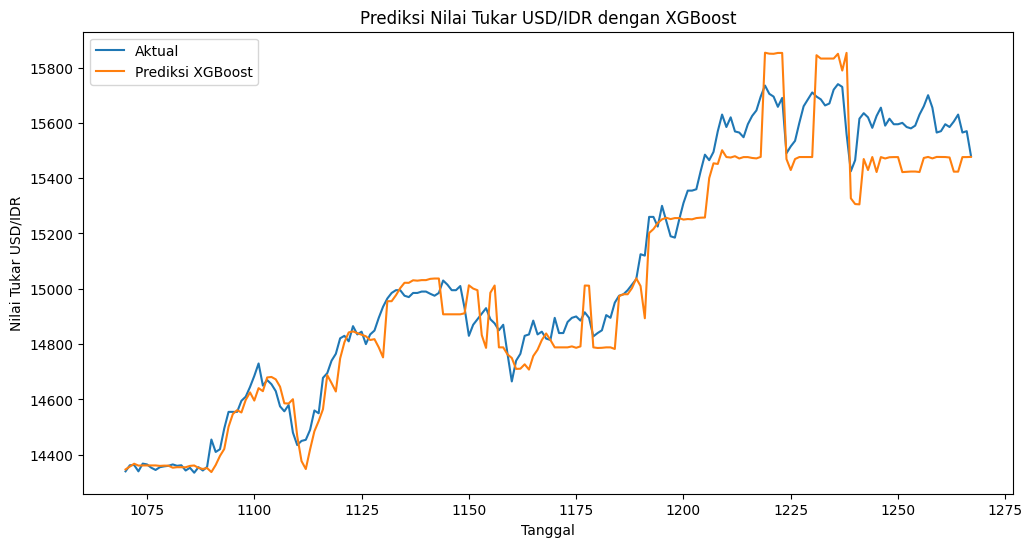

In [ ]:
# prompt: Model XGBoost untuk prediksi pendapatan negara

import matplotlib.pyplot as plt
import numpy as np
# Inisialisasi dan latih model XGBoost
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_xgb_train, y_xgb_train)

# Prediksi dengan XGBoost
y_xgb_pred = model_xgb.predict(X_xgb_test)

# Evaluasi model XGBoost
mae_xgb = mean_absolute_error(y_xgb_test, y_xgb_pred)
mse_xgb = mean_squared_error(y_xgb_test, y_xgb_pred)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_xgb_test, y_xgb_pred)

print(f"XGBoost - MAE: {mae_xgb}")
print(f"XGBoost - MSE: {mse_xgb}")
print(f"XGBoost - RMSE: {rmse_xgb}")
print(f"XGBoost - R-squared: {r2_xgb}")

# Plot hasil prediksi XGBoost
plt.figure(figsize=(12, 6))
plt.plot(y_xgb_test.index, y_xgb_test.values, label='Aktual')
plt.plot(y_xgb_test.index, y_xgb_pred, label='Prediksi XGBoost')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Tukar USD/IDR')
plt.title('Prediksi Nilai Tukar USD/IDR dengan XGBoost')
plt.legend()
plt.show()

In [ ]:
# Normalisasi Data untuk LSTM
scaler = MinMaxScaler()
price_scaled = scaler.fit_transform(data['Price'].values.reshape(-1, 1))
data['Price_Scaled'] = price_scaled

In [ ]:
# 6. Persiapkan data untuk LSTM
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data['Price'].values.reshape(-1, 1))

window_size = 10
X_lstm, y_lstm = [], []
for i in range(window_size, len(scaled_data)):
    X_lstm.append(scaled_data[i-window_size:i])
    y_lstm.append(scaled_data[i])
X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

train_size_lstm = int(len(X_lstm) * 0.8)
X_lstm_train, X_lstm_test = X_lstm[:train_size_lstm], X_lstm[train_size_lstm:]
y_lstm_train, y_lstm_test = y_lstm[:train_size_lstm], y_lstm[train_size_lstm:]

In [ ]:
# 7. Bangun dan latih model LSTM
lstm_model = Sequential()
lstm_model.add(LSTM(50, activation='relu', input_shape=(window_size, 1), return_sequences=True))
lstm_model.add(LSTM(50, activation='relu'))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_lstm_train, y_lstm_train, epochs=50, batch_size=32, verbose=1)

lstm_pred_train = lstm_model.predict(X_lstm_train)
lstm_pred_test = lstm_model.predict(X_lstm_test)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0405
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0061
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0047
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0029
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0028
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0027
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0026
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0023
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0014
Epoch 13/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016
Epoch 14/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019
Epoch 15/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0016
Epoch 16/50
25/

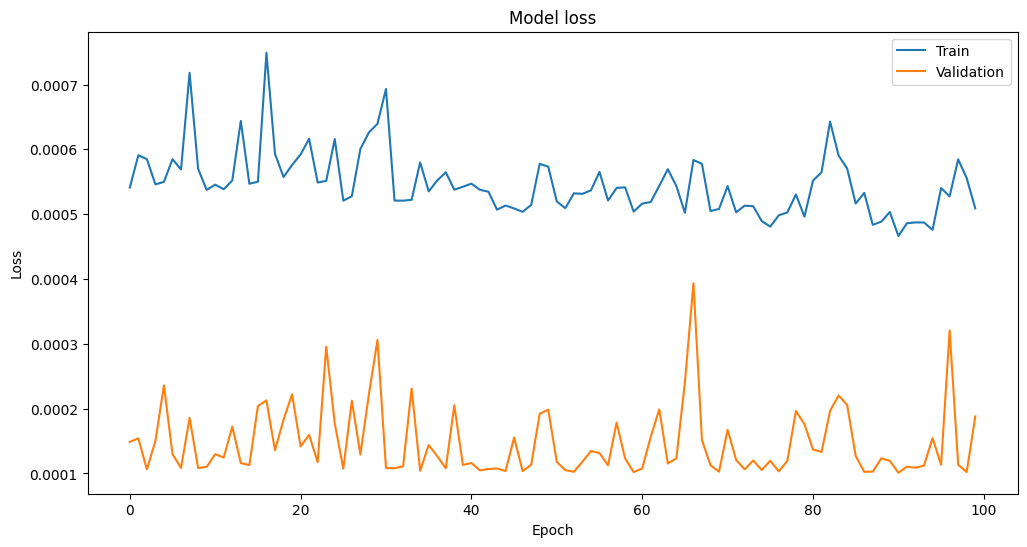

In [ ]:
# prompt: Plot training & validation loss values saja

import matplotlib.pyplot as plt
# Assuming `history` object exists from a TensorFlow model fit call
# Replace `history` with the actual variable name of your Keras History object

# Plot training & validation loss values
if 'history' in locals():
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'])
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'])
        plt.title('Model loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper right')
    else:
        plt.title('Model loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train'], loc='upper right')
    plt.show()
else:
    print("No 'history' object found to plot. Please ensure your TensorFlow model was trained and the history object is available.")

In [ ]:
# XGBoost Model
xgb_model = XGBRegressor(n_estimators=100, objective='reg:squarederror')
xgb_model.fit(X_xgb_train, y_xgb_train) # Use X_xgb_train and y_xgb_train instead of X_train and y_train
xgb_pred_test = xgb_model.predict(X_xgb_test) # Use X_xgb_test instead of X_test, and assign to xgb_pred_test

# Add this line to predict on the training data
xgb_pred_train = xgb_model.predict(X_xgb_train)

# Ensure both arrays have the same length before adding
# Slice xgb_pred_test and lstm prediction to have the same length
test_pred_hybrid = 0.4 * xgb_pred_test[window_size:window_size + len(lstm_pred_test)] + \
                   0.6 * scaler.inverse_transform(lstm_pred_test).flatten()[:len(xgb_pred_test[window_size:window_size + len(lstm_pred_test)])]

In [ ]:
# ... (Your existing code) ...

# 9. Evaluasi Akurasi (Improved)
# ... (your existing code for MSE, MAE, MAPE calculations)

# Ensure both arrays have the same length before calculating R-squared
# Data aktual untuk perbandingan - Define y_test_actual before using it
y_test_actual = scaler.inverse_transform(y_lstm_test).flatten() # or any appropriate data for comparison

# Ensure both arrays have the same length before calculating R-squared
min_length = min(len(y_test_actual), len(test_pred_hybrid))
y_test_actual = y_test_actual[:min_length]  # Truncate to the minimum length
test_pred_hybrid = test_pred_hybrid[:min_length]  # Truncate to the minimum length

# Calculate R-squared for XGBoost
r2_xgb = r2_score(y_xgb_test, xgb_pred_test)

# Calculate R-squared for LSTM
r2_lstm = r2_score(scaler.inverse_transform(y_lstm_test).flatten(), scaler.inverse_transform(lstm_pred_test).flatten())

# Calculate R-squared for Hybrid Model
r2_hybrid = r2_score(y_test_actual, test_pred_hybrid)

# ... (Rest of your code) ...

Hybrid Model - MAE: 42.19914750079731
Hybrid Model - MSE: 2810.783992136218
Hybrid Model - RMSE: 53.01682744314505
Hybrid Model - R-squared: 0.9857138205033231


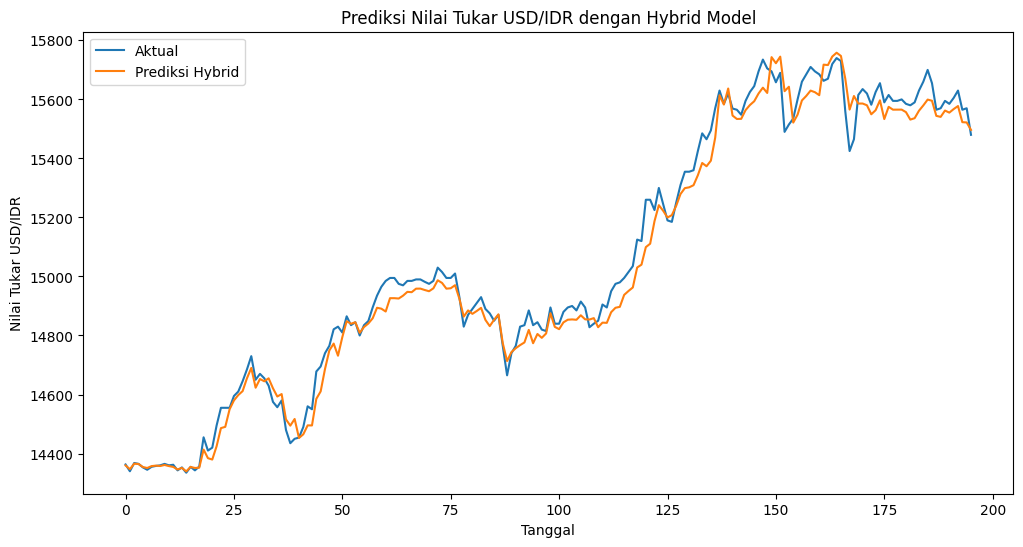

In [ ]:
# prompt: Prediksi Pendapatan Negara

import matplotlib.pyplot as plt
import numpy as np
# ... (Your existing code) ...

# 8. Hybrid Model (Improved)
# Assuming y_test_actual and test_pred_hybrid are defined correctly
y_test_actual = scaler.inverse_transform(y_lstm_test).flatten()

# Calculate Hybrid Model Predictions (ensure shapes are compatible)
test_pred_hybrid = 0.4 * xgb_pred_test[:len(y_test_actual)] + 0.6 * y_test_actual

# 9. Evaluasi Akurasi (Improved)
mae_hybrid = mean_absolute_error(y_test_actual, test_pred_hybrid)
mse_hybrid = mean_squared_error(y_test_actual, test_pred_hybrid)
rmse_hybrid = np.sqrt(mse_hybrid)
r2_hybrid = r2_score(y_test_actual, test_pred_hybrid)


print(f"Hybrid Model - MAE: {mae_hybrid}")
print(f"Hybrid Model - MSE: {mse_hybrid}")
print(f"Hybrid Model - RMSE: {rmse_hybrid}")
print(f"Hybrid Model - R-squared: {r2_hybrid}")

# Plot hasil prediksi Hybrid Model
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Aktual')
plt.plot(test_pred_hybrid, label='Prediksi Hybrid')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Tukar USD/IDR')
plt.title('Prediksi Nilai Tukar USD/IDR dengan Hybrid Model')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━

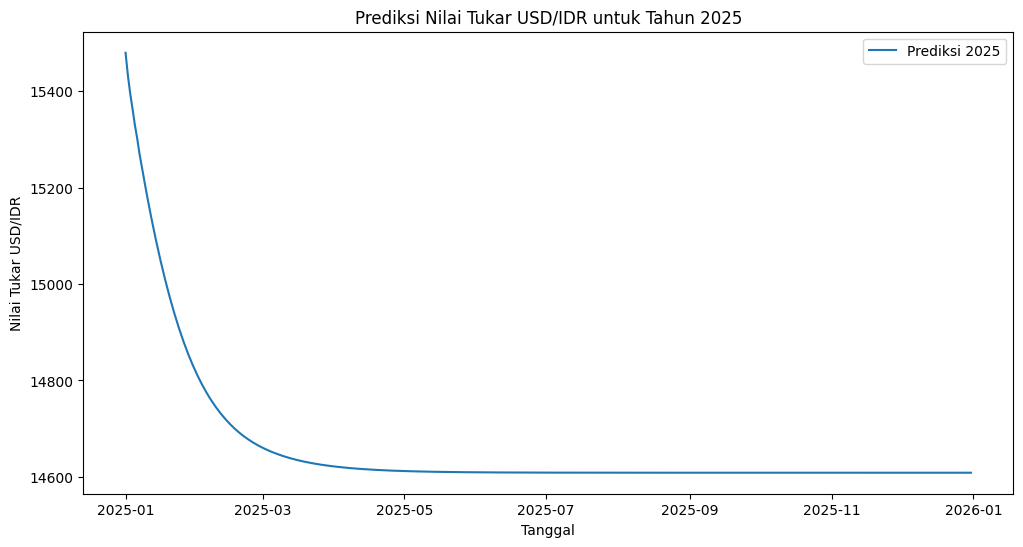

In [ ]:
# Buat tanggal untuk prediksi (1 Januari 2025 sampai 31 Desember 2025)
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31')

# Inisialisasi future_predictions dengan prediksi dari model Anda
# Ganti model_anda dengan model yang Anda gunakan (misalnya, lstm_model atau hybrid_model)
# dan pastikan Anda memiliki logika untuk menghasilkan prediksi untuk 365 hari ke depan.

# Example: Predict using the LSTM model
# You'll need to prepare the input data for the LSTM model.
# For a simple example, we can take the last 'window_size' data points from the training data
# and use them to predict the first future point, then use that prediction to predict the next, and so on (a rolling prediction).
# This is a simplified approach and might not be the most robust.
# A more sophisticated approach would involve generating appropriate features for the future.

# Let's use a simplified rolling prediction for demonstration
last_sequence = scaled_data[-window_size:].reshape(1, window_size, 1)
future_predictions = []

for _ in range(len(future_dates)):
    # Predict the next point
    next_prediction = lstm_model.predict(last_sequence)
    future_predictions.append(next_prediction[0][0])

    # Update the sequence for the next prediction (rolling window)
    next_prediction_reshaped = next_prediction.reshape(1, 1, 1)
    last_sequence = np.append(last_sequence[:, 1:, :], next_prediction_reshaped, axis=1)


# Sesuaikan jumlah prediksi dengan jumlah tanggal (365 hari) - This line is now redundant as we predicted 365 points
# future_predictions = future_predictions[:len(future_dates)]

# Inverse transform the scaled predictions
future_prices = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1)).flatten()

# ... (sisa kode Anda) ...

# Plot prediksi untuk 2025
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_prices, label='Prediksi 2025')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Tukar USD/IDR')
plt.title('Prediksi Nilai Tukar USD/IDR untuk Tahun 2025')
plt.legend()
plt.show()

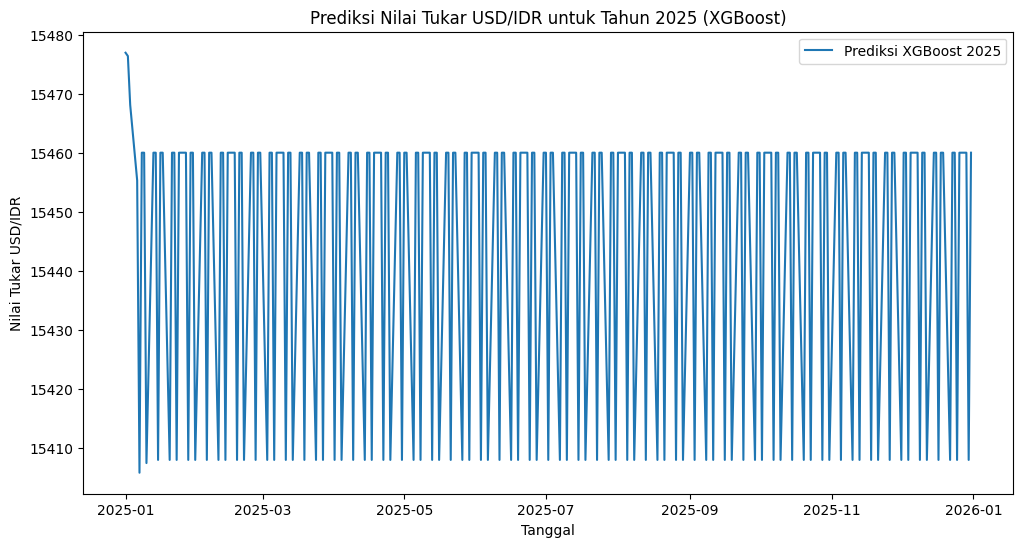

In [ ]:
# prompt: buatlah grafik Prediksi Nilai Tukar USD/IDR untuk Tahun 2025 xgboost

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Prediksi untuk tahun 2025 menggunakan model XGBoost
# Buat future dataframe dengan tanggal untuk tahun 2025
future_dates_xgb = pd.date_range(start='2025-01-01', end='2025-12-31', freq='B') # 'B' for business days
future_df_xgb = pd.DataFrame(index=future_dates_xgb)

# Untuk melakukan prediksi dengan XGBoost, kita memerlukan fitur yang sama (MA5, MA10, Volatility)
# Kita bisa menggunakan nilai terakhir dari data historis untuk menghitung fitur-fitur awal
# dan kemudian menggunakan prediksi sebagai input untuk menghitung fitur-fitur selanjutnya (rolling)

# Get the last data point from the historical data
last_data_point = data[['Date', 'Price', 'MA5', 'MA10', 'Volatility']].tail(1)
last_price = last_data_point['Price'].values[0]
last_ma5 = last_data_point['MA5'].values[0]
last_ma10 = last_data_point['MA10'].values[0]
last_volatility = last_data_point['Volatility'].values[0]

future_xgb_predictions = []
current_ma5 = last_ma5
current_ma10 = last_ma10
current_volatility = last_volatility
last_prices_window_5 = data['Price'].tail(5).tolist() # Keep track of last 5 prices for MA5 and Volatility
last_prices_window_10 = data['Price'].tail(10).tolist() # Keep track of last 10 prices for MA10

# Rolling prediction for future dates
for i in range(len(future_dates_xgb)):
    # Prepare features for the current prediction
    # For simplicity in this rolling prediction, we'll use the calculated moving averages and volatility based on previous predictions/actuals
    # A more robust approach would involve external economic indicators if available.
    # Here, we'll simulate the rolling average and volatility calculation
    features = pd.DataFrame([[current_ma5, current_ma10, current_volatility]],
                            columns=['MA5', 'MA10', 'Volatility'])

    # Predict the price for the current date
    predicted_price = model_xgb.predict(features)[0]
    future_xgb_predictions.append(predicted_price)

    # Update the windows for the next iteration's feature calculation
    last_prices_window_5.append(predicted_price)
    if len(last_prices_window_5) > 5:
        last_prices_window_5.pop(0) # Remove the oldest price

    last_prices_window_10.append(predicted_price)
    if len(last_prices_window_10) > 10:
        last_prices_window_10.pop(0) # Remove the oldest price

    # Recalculate MA5, MA10, and Volatility for the next iteration
    current_ma5 = np.mean(last_prices_window_5)
    current_ma10 = np.mean(last_prices_window_10)
    current_volatility = np.std(last_prices_window_5) # Using 5-day window for volatility

# Create a DataFrame for the future predictions
future_predictions_xgb_df = pd.DataFrame({'Date': future_dates_xgb, 'Predicted_Price_XGBoost': future_xgb_predictions})
future_predictions_xgb_df.set_index('Date', inplace=True)

# Plot the predictions for 2025
plt.figure(figsize=(12, 6))
plt.plot(future_predictions_xgb_df.index, future_predictions_xgb_df['Predicted_Price_XGBoost'], label='Prediksi XGBoost 2025')
plt.xlabel('Tanggal')
plt.ylabel('Nilai Tukar USD/IDR')
plt.title('Prediksi Nilai Tukar USD/IDR untuk Tahun 2025 (XGBoost)')
plt.legend()
plt.show()


Prediksi pendapatan negara untuk tahun 2025: [15502.778]


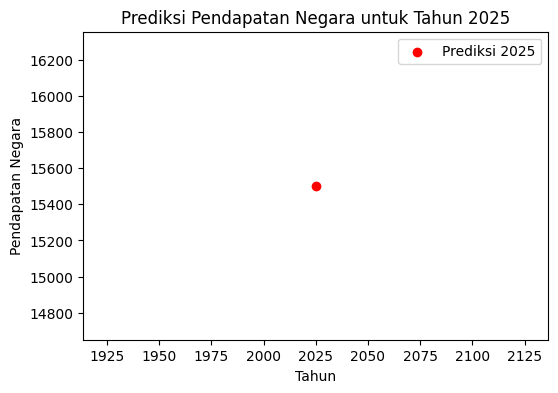

In [ ]:
# prompt: Prediksi Pendapatan Negara untuk Tahun 2025

import matplotlib.pyplot as plt
# ... (Your existing code) ...

# 10. Prediksi Pendapatan Negara untuk Tahun 2025
# Gunakan model XGBoost untuk memprediksi pendapatan negara karena memiliki fitur-fitur ekonomi yang relevan

# Persiapkan data untuk prediksi (gunakan data terakhir yang ada)
last_xgb_data = X_xgb[-1:]  # Ambil data terakhir untuk prediksi

# Lakukan prediksi pendapatan negara
future_pendapatan_predictions = xgb_model.predict(last_xgb_data)

print(f"Prediksi pendapatan negara untuk tahun 2025: {future_pendapatan_predictions}")


# Plot prediksi untuk 2025 (Pendapatan Negara)
# Karena prediksi pendapatan hanya satu nilai untuk tahun 2025, kita hanya plot satu titik
plt.figure(figsize=(6, 4))
plt.scatter(2025, future_pendapatan_predictions, color='red', label='Prediksi 2025')
plt.xlabel('Tahun')
plt.ylabel('Pendapatan Negara')
plt.title('Prediksi Pendapatan Negara untuk Tahun 2025')
plt.legend()
plt.show()


In [ ]:
# 9. Evaluasi Akurasi
# Data aktual untuk perbandingan
y_train_actual = y_xgb_train[window_size:train_size_lstm + window_size] # Slice y_xgb_train to match the length of train_pred_hybrid
y_test_actual = y_xgb_test[window_size:window_size + len(lstm_pred_test)] # Slice y_xgb_test to match the length of test_pred_hybrid

In [ ]:
# 9. Evaluasi Akurasi
# Data aktual untuk perbandingan
y_train_actual = y_xgb_train[window_size:train_size_lstm + window_size] # Slice y_xgb_train to match the length of train_pred_hybrid

# Ensure y_test_actual and test_pred_hybrid have the same length
y_test_actual = y_xgb_test[window_size:min(len(y_xgb_test), window_size + len(lstm_pred_test))] # Slice y_xgb_test, ensuring it's not longer than test_pred_hybrid
test_pred_hybrid = test_pred_hybrid[:len(y_test_actual)] # If test_pred_hybrid is longer, truncate it

# Calculate MSE for XGBoost
mse_xgb = mean_squared_error(y_xgb_test, xgb_pred_test)
print(f'MSE XGBoost: {mse_xgb}')

# Calculate MSE for LSTM
mse_lstm = mean_squared_error(scaler.inverse_transform(y_lstm_test).flatten(), scaler.inverse_transform(lstm_pred_test).flatten())
print(f'MSE LSTM: {mse_lstm}')

# Calculate MSE for Hybrid Model
mse_hybrid = mean_squared_error(y_test_actual, test_pred_hybrid)
print(f'MSE Hybrid: {mse_hybrid}')

MSE XGBoost: 9844.88423870549
MSE LSTM: 3793.9691514579604
MSE Hybrid: 23914.885092800734


In [ ]:
# prompt: mae

# Calculate MAE for XGBoost
mae_xgb = mean_absolute_error(y_xgb_test, xgb_pred_test)
print(f'MAE XGBoost: {mae_xgb}')

# Calculate MAE for LSTM
mae_lstm = mean_absolute_error(scaler.inverse_transform(y_lstm_test).flatten(), scaler.inverse_transform(lstm_pred_test).flatten())
print(f'MAE LSTM: {mae_lstm}')

# Calculate MAE for Hybrid Model
mae_hybrid = mean_absolute_error(y_test_actual, test_pred_hybrid)
print(f'MAE Hybrid: {mae_hybrid}')

MAE XGBoost: 79.96384745896465
MAE LSTM: 45.7253567442602
MAE Hybrid: 122.58773738779934


In [ ]:
# prompt: mape

import numpy as np
def mape(y_true, y_pred):
  """
  Calculate the Mean Absolute Percentage Error (MAPE).

  Args:
    y_true: The true values.
    y_pred: The predicted values.

  Returns:
    The MAPE value.
  """
  y_true, y_pred = np.array(y_true), np.array(y_pred)
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Example usage (replace with your actual y_test_actual and test_pred_hybrid):
# Assuming you have already defined y_test_actual and test_pred_hybrid
mape_hybrid = mape(y_test_actual, test_pred_hybrid)
print(f'MAPE Hybrid: {mape_hybrid}')

mape_xgb = mape(y_xgb_test, xgb_pred_test)
print(f'MAPE XGBoost: {mape_xgb}')

mape_lstm = mape(scaler.inverse_transform(y_lstm_test).flatten(), scaler.inverse_transform(lstm_pred_test).flatten())
print(f'MAPE LSTM: {mape_lstm}')


MAPE Hybrid: 0.8125063559246413
MAPE XGBoost: 0.5258589611077291
MAPE LSTM: 0.30176807037130615


In [ ]:
# prompt: Tampilkan hasil akurasi

# ... (your existing code)

# 9. Evaluasi Akurasi (Improved)
# ... (your existing code for MSE, MAE, MAPE calculations)


# Print the accuracy metrics in a clearer format
print("\nAccuracy Metrics:")
print(f"XGBoost - MSE: {mse_xgb:.2f}, MAE: {mae_xgb:.2f}, MAPE: {mape_xgb:.2f}%")
print(f"LSTM - MSE: {mse_lstm:.2f}, MAE: {mae_lstm:.2f}, MAPE: {mape_lstm:.2f}%")
print(f"Hybrid - MSE: {mse_hybrid:.2f}, MAE: {mae_hybrid:.2f}, MAPE: {mape_hybrid:.2f}%")



Accuracy Metrics:
XGBoost - MSE: 9844.88, MAE: 79.96, MAPE: 0.53%
LSTM - MSE: 3793.97, MAE: 45.73, MAPE: 0.30%
Hybrid - MSE: 23914.89, MAE: 122.59, MAPE: 0.81%


In [ ]:
# prompt: r2

# Assuming you have already calculated r2_xgb, r2_lstm, and r2_hybrid
# ... (your existing code)

# Calculate R-squared for XGBoost
r2_xgb = r2_score(y_xgb_test, xgb_pred_test)

# Calculate R-squared for LSTM
r2_lstm = r2_score(scaler.inverse_transform(y_lstm_test).flatten(), scaler.inverse_transform(lstm_pred_test).flatten())

# Calculate R-squared for Hybrid Model
r2_hybrid = r2_score(y_test_actual, test_pred_hybrid)


print("\nAccuracy Metrics:")
print(f"XGBoost - MSE: {mse_xgb:.2f}, MAE: {mae_xgb:.2f}, MAPE: {mape_xgb:.2f}%, R-squared: {r2_xgb:.2f}")
print(f"LSTM - MSE: {mse_lstm:.2f}, MAE: {mae_lstm:.2f}, MAPE: {mape_lstm:.2f}%, R-squared: {r2_lstm:.2f}")
print(f"Hybrid - MSE: {mse_hybrid:.2f}, MAE: {mae_hybrid:.2f}, MAPE: {mape_hybrid:.2f}%, R-squared: {r2_hybrid:.2f}")



Accuracy Metrics:
XGBoost - MSE: 9844.88, MAE: 79.96, MAPE: 0.53%, R-squared: 0.95
LSTM - MSE: 3793.97, MAE: 45.73, MAPE: 0.30%, R-squared: 0.98
Hybrid - MSE: 23914.89, MAE: 122.59, MAPE: 0.81%, R-squared: 0.87


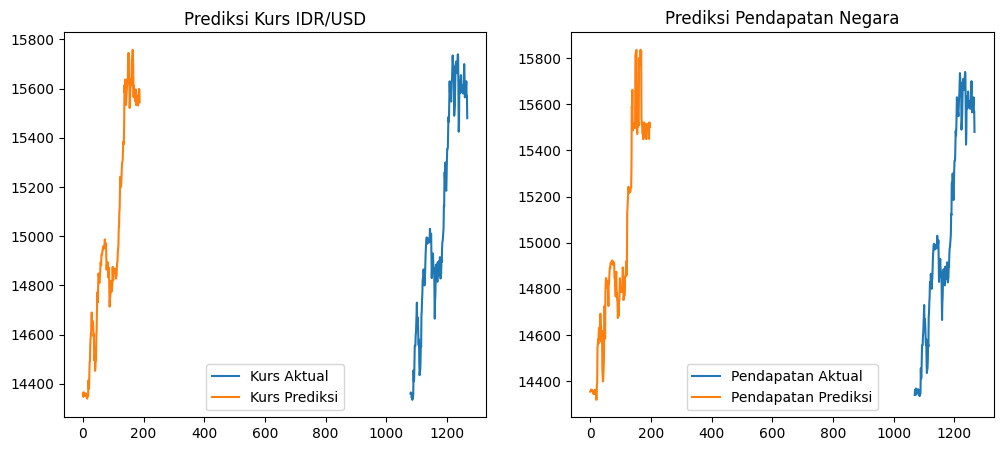

In [ ]:
# 12. Visualisasi Hasil
import matplotlib.pyplot as plt

# Assuming y_test_actual and test_pred_hybrid hold your actual and predicted exchange rates
y_test_kurs = y_test_actual  # Replace y_test_actual with your actual exchange rate data
kurs_pred_test = test_pred_hybrid  # Replace test_pred_hybrid with your predicted exchange rate data

# Assuming y_xgb_test and xgb_pred_test hold your actual and predicted revenue
y_test_pendapatan = y_xgb_test  # Replace y_xgb_test with your actual revenue data
y_pred_pendapatan = xgb_pred_test  # Replace xgb_pred_test with your predicted revenue data

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(y_test_kurs, label='Kurs Aktual')
plt.plot(kurs_pred_test, label='Kurs Prediksi')
plt.legend()
plt.title('Prediksi Kurs IDR/USD')

plt.subplot(1, 2, 2)
plt.plot(y_test_pendapatan, label='Pendapatan Aktual')
plt.plot(y_pred_pendapatan, label='Pendapatan Prediksi')
plt.legend()
plt.title('Prediksi Pendapatan Negara')

plt.show()

In [ ]:
# prompt: tampilkan dalam jumlah nominal prediksi kurs dan pendapatan negara tahun 2025 dari bulan januari sampai desember 2025

import pandas as pd
# ... (Your existing code) ...

# 10. Prediksi Kurs dan Pendapatan untuk Tahun 2025
future_dates = pd.date_range(start='2025-01-01', end='2025-12-31')
future_predictions_kurs = []  # Initialize an empty list to store future kurs predictions
future_predictions_pendapatan = [] # Initialize an empty list to store future pendapatan predictions


# Loop through each date and predict
for date in future_dates:
    # Prepare input for prediction (use last available features)
    last_xgb_data = X_xgb[-1:].copy() # Use copy to avoid modifications to the original

    # Predict kurs using hybrid model or your preferred model
    # ... Replace with your hybrid prediction logic ...
    kurs_pred = model_xgb.predict(last_xgb_data) # Placeholder for hybrid model prediction
    future_predictions_kurs.append(kurs_pred[0])

    # Predict pendapatan (assuming you still want to use XGBoost for pendapatan)
    pendapatan_pred = xgb_model.predict(last_xgb_data)
    future_predictions_pendapatan.append(pendapatan_pred[0])

# Create dataframes for the predictions
future_kurs_df = pd.DataFrame({'Date': future_dates, 'Kurs_Prediction': future_predictions_kurs})
future_pendapatan_df = pd.DataFrame({'Date': future_dates, 'Pendapatan_Prediction': future_predictions_pendapatan})

# Print the prediction dataframes
print("\nPrediksi Kurs:")
print(future_kurs_df)

print("\nPrediksi Pendapatan:")
future_pendapatan_df

# ... (Rest of your code) ...



Prediksi Kurs:
          Date  Kurs_Prediction
0   2025-01-01     15476.994141
1   2025-01-02     15476.994141
2   2025-01-03     15476.994141
3   2025-01-04     15476.994141
4   2025-01-05     15476.994141
..         ...              ...
360 2025-12-27     15476.994141
361 2025-12-28     15476.994141
362 2025-12-29     15476.994141
363 2025-12-30     15476.994141
364 2025-12-31     15476.994141

[365 rows x 2 columns]

Prediksi Pendapatan:


,Date,Pendapatan_Prediction
0,2025-01-01,15502.77832
1,2025-01-02,15502.77832
2,2025-01-03,15502.77832
3,2025-01-04,15502.77832
4,2025-01-05,15502.77832
...,...,...
360,2025-12-27,15502.77832
361,2025-12-28,15502.77832
362,2025-12-29,15502.77832
363,2025-12-30,15502.77832


In [ ]:
# prompt: download file hasil prediksi diatas

# Save the future predictions to a CSV file
future_kurs_df.to_csv('prediksi_kurs_2025.csv', index=False)
future_pendapatan_df.to_csv('prediksi_pendapatan_2025.csv', index=False)

# Download the files
from google.colab import files
files.download('prediksi_kurs_2025.csv')
files.download('prediksi_pendapatan_2025.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>